In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

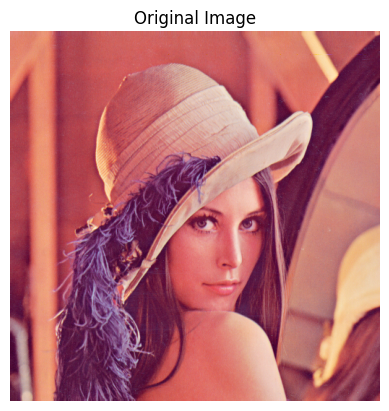

In [2]:
# Read image
img = Image.open("Lenna_(test_image).png")

# Convert to numpy array
img_array = np.array(img)

# Display image
plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")
plt.show()

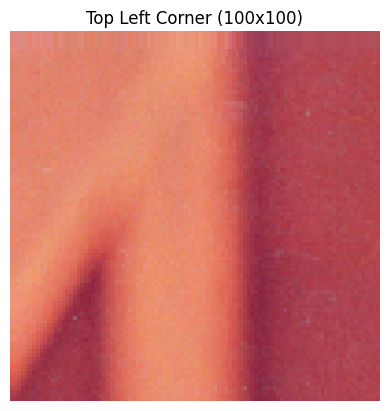

In [3]:
# Extract top-left 100x100 pixels
top_left = img_array[0:100, 0:100]

# Display
plt.imshow(top_left)
plt.title("Top Left Corner (100x100)")
plt.axis("off")
plt.show()

In [4]:
# Extract channels
red = img_array[:,:,0]
green = img_array[:,:,1]
blue = img_array[:,:,2]

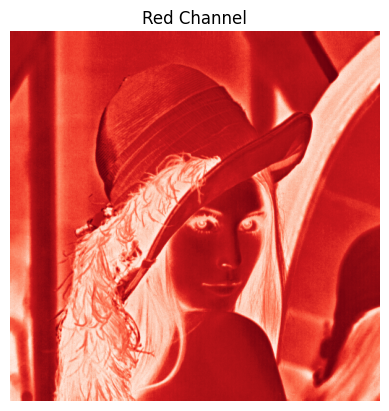

In [5]:
plt.imshow(red, cmap='Reds')
plt.title("Red Channel")
plt.axis("off")
plt.show()

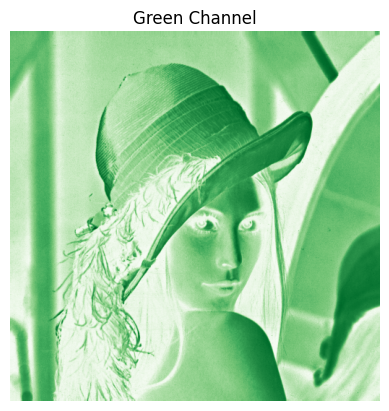

In [6]:
plt.imshow(green, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")
plt.show()

In [7]:
# Copy image so original remains unchanged
modified_img = img_array.copy()

# Change top-left 100x100 pixels
modified_img[0:100, 0:100] = 210

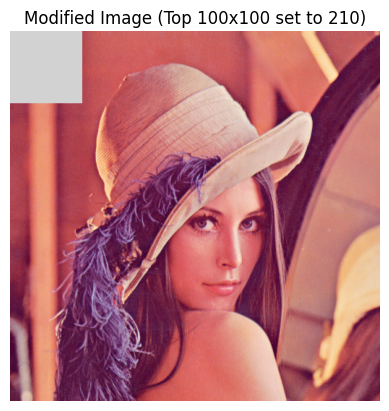

In [8]:
plt.imshow(modified_img)
plt.title("Modified Image (Top 100x100 set to 210)")
plt.axis("off")
plt.show()

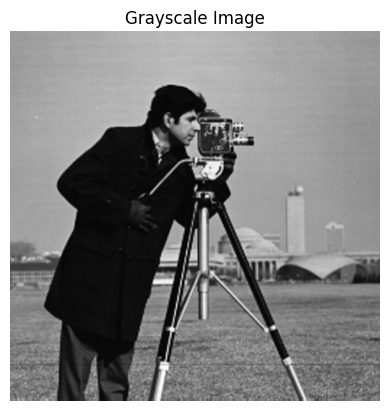

In [11]:
# Load image and convert to grayscale
img = Image.open("cameraman.png").convert("L")

# Convert to numpy array
img_array = np.array(img)

# Display grayscale image
plt.imshow(img_array, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

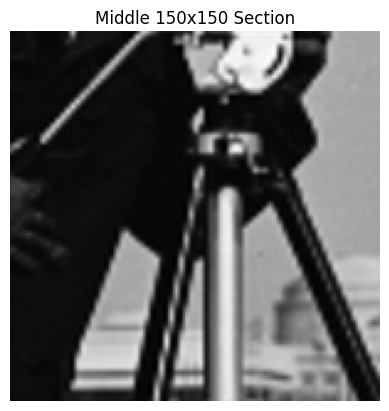

In [12]:
h, w = img_array.shape

# center coordinates
center_x = w // 2
center_y = h // 2

# crop 150x150 region
middle_section = img_array[center_y-75:center_y+75, center_x-75:center_x+75]

plt.imshow(middle_section, cmap='gray')
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

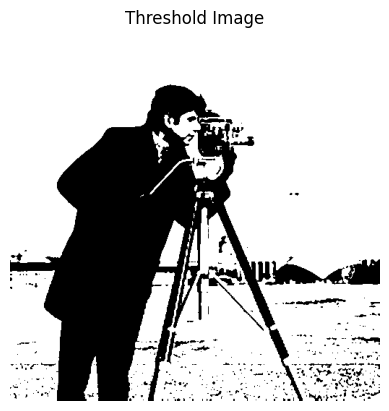

In [14]:
binary_img = img_array.copy()

binary_img[binary_img < 100] = 0
binary_img[binary_img >= 100] = 255

plt.imshow(binary_img, cmap='gray')
plt.title("Threshold Image")
plt.axis("off")
plt.show()

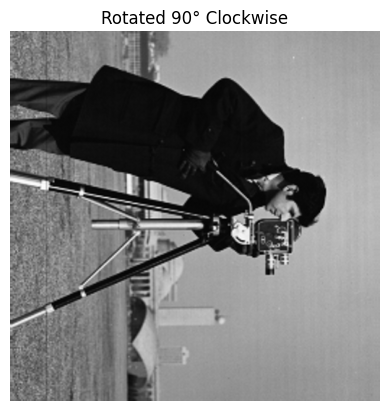

In [15]:
rotated_img = np.rot90(img_array, k=-1)

plt.imshow(rotated_img, cmap='gray')
plt.title("Rotated 90° Clockwise")
plt.axis("off")
plt.show()

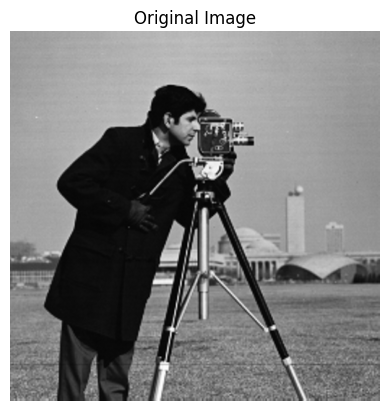

In [27]:
# Load grayscale image
img = Image.open("cameraman.png").convert("L")
img_array = np.array(img)

plt.imshow(img_array, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

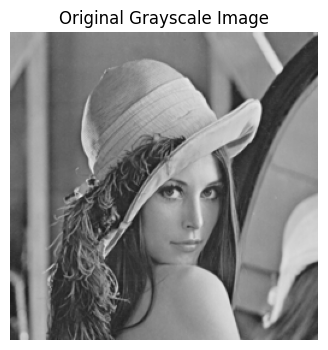

Image shape: (256, 256)


In [28]:
img = Image.open("lena_gray.gif").convert("L")
img = img.resize((256, 256))
img_array = np.array(img, dtype=float)

plt.figure(figsize=(4, 4))
plt.imshow(img_array, cmap="gray", vmin=0, vmax=255)
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

print(f"Image shape: {img_array.shape}")

In [40]:
mean_vec = np.mean(img_array, axis=0)
std_vec  = np.std(img_array,  axis=0) + 1e-8
X_std    = (img_array - mean_vec) / std_vec

cov_matrix = (X_std.T @ X_std) / (img_array.shape[0] - 1)

print(f"Mean vector shape   : {mean_vec.shape}")
print(f"Standardized shape  : {X_std.shape}")
print(f"Covariance matrix   : {cov_matrix.shape}")

Mean vector shape   : (256,)
Standardized shape  : (256, 256)
Covariance matrix   : (256, 256)


In [39]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

idx          = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print(f"Eigenvalues  shape: {eigenvalues.shape}")
print(f"Eigenvectors shape: {eigenvectors.shape}")
print(f"\nTop 10 eigenvalues: {eigenvalues[:10].round(2)}")

Eigenvalues  shape: (256,)
Eigenvectors shape: (256, 256)

Top 10 eigenvalues: [59.27 39.64 24.41 21.57 17.07 12.76 11.18  6.57  5.13  4.68]


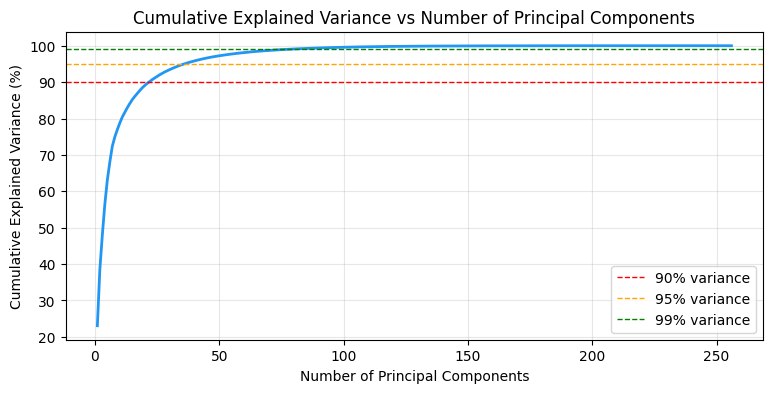

90% variance → 22 components
95% variance → 36 components
99% variance → 77 components


In [32]:
total_var     = np.sum(eigenvalues)
explained     = eigenvalues / total_var
cum_explained = np.cumsum(explained)

plt.figure(figsize=(9, 4))
plt.plot(np.arange(1, len(cum_explained) + 1), cum_explained * 100, color="#2196F3", linewidth=2)
plt.axhline(90, color="red",    linestyle="--", linewidth=1, label="90% variance")
plt.axhline(95, color="orange", linestyle="--", linewidth=1, label="95% variance")
plt.axhline(99, color="green",  linestyle="--", linewidth=1, label="99% variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance vs Number of Principal Components")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for thresh in [0.90, 0.95, 0.99]:
    k = int(np.searchsorted(cum_explained, thresh)) + 1
    print(f"{thresh*100:.0f}% variance → {k} components")

In [41]:
def reconstruct(X_std, eigvecs, mean_vec, std_vec, k):
    PC_k    = eigvecs[:, :k]
    scores  = X_std @ PC_k
    X_recon = scores @ PC_k.T
    img_recon = X_recon * std_vec + mean_vec
    return np.clip(img_recon, 0, 255)

test_recon = reconstruct(X_std, eigenvectors, mean_vec, std_vec, 50)
print(f"Reconstructed image shape: {test_recon.shape}")

Reconstructed image shape: (256, 256)


In [34]:
k_values = [10, 20, 50, 100, 150]
reconstructions = {}

for k in k_values:
    reconstructions[k] = reconstruct(X_std, eigenvectors, mean_vec, std_vec, k)
    ev = cum_explained[k - 1] * 100
    print(f"k={k:>4d}  →  Cumulative Explained Variance = {ev:.2f}%")

k=  10  →  Cumulative Explained Variance = 78.71%
k=  20  →  Cumulative Explained Variance = 89.04%
k=  50  →  Cumulative Explained Variance = 97.24%
k= 100  →  Cumulative Explained Variance = 99.58%
k= 150  →  Cumulative Explained Variance = 99.95%


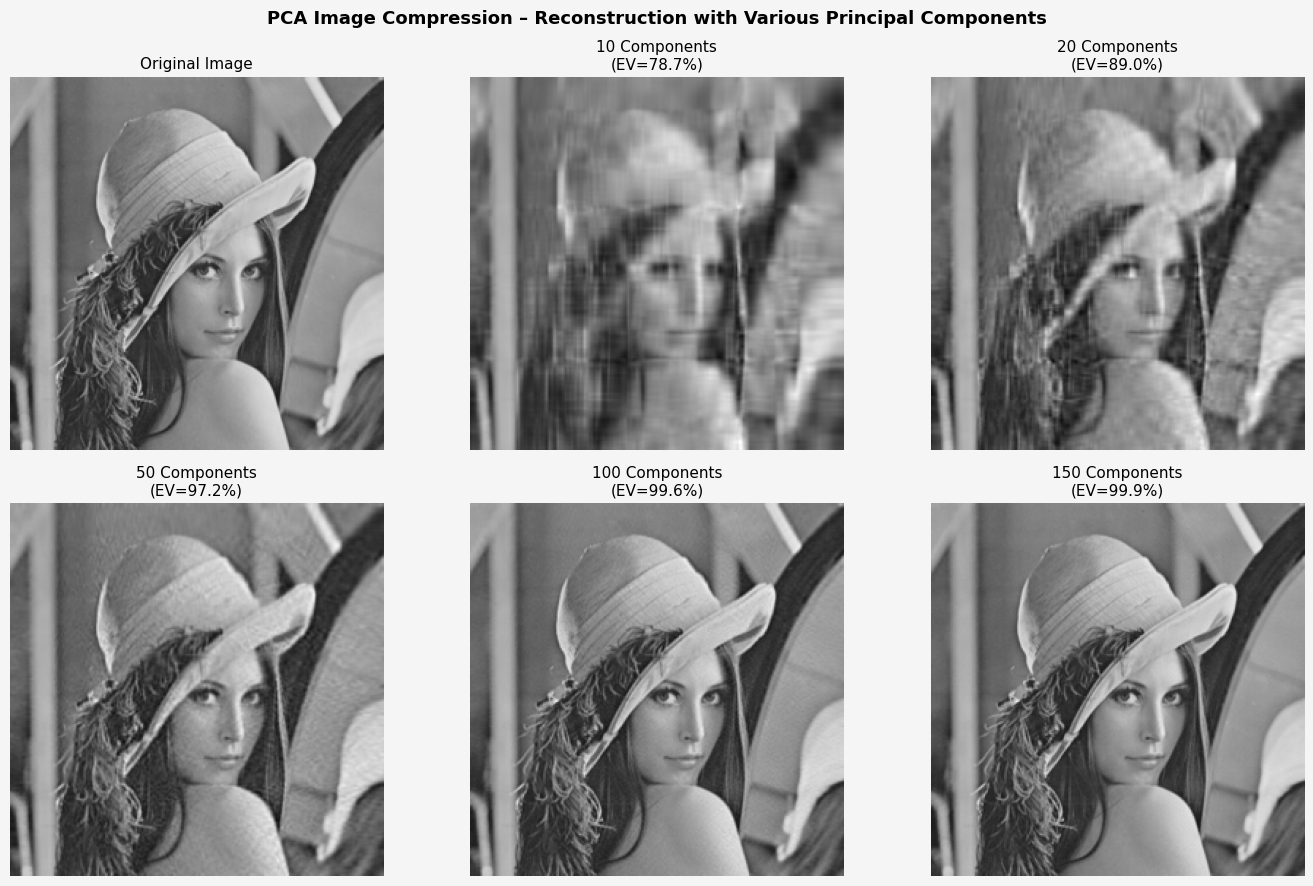

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.patch.set_facecolor("#f5f5f5")

panels = [("Original Image", img_array, None)] + \
         [(f"{k} Components\n(EV={cum_explained[k-1]*100:.1f}%)", reconstructions[k], k)
          for k in k_values]

for ax, (title, data, k) in zip(axes.flat, panels):
    ax.imshow(data, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title, fontsize=11)
    ax.axis("off")
    if k is not None:
        mse  = np.mean((img_array - data) ** 2)
        psnr = 10 * np.log10(255**2 / mse)
        compression = (k * (img_array.shape[0] + img_array.shape[1])) / img_array.size * 100
        ax.set_xlabel(f"PSNR: {psnr:.1f} dB  |  Storage: {compression:.1f}%", fontsize=8)
        ax.xaxis.set_visible(True)
        ax.tick_params(bottom=False, labelbottom=True)

fig.suptitle("PCA Image Compression – Reconstruction with Various Principal Components",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()